# TinyML Lab 1 — Real-Time Rotational Dynamics & Edge-AI Payload Safety System

This notebook implements the 10-step workflow: **Problem → Setup → Data Acquisition → Preprocess/Features → Train → Evaluate → Convert to TFLite → Quantize → Convert to `.h` → Deploy at the Edge**.

Run the cells top to bottom. Replace `phyphox_gyro_data.csv` with your own exported file from phyphox.

## Step 1 — Problem & Objective

**Goal:** predict whether a payload (coin / eraser) on a rotating platform is **SAFE (0)** or **UNSAFE (1)** using smartphone gyroscope data and a lightweight TinyML model.

**Plan**
1. Understand the task
2. Decide the data collection setup
3. Design preprocessing, features and model
4. Prepare for edge deployment

**Physical basis:** the payload slides once the centripetal force needed to keep it turning, `F = m·ω²·r`, exceeds the static friction available, `μs·m·g`. Angular velocity ω is therefore a direct proxy for how close the payload is to sliding.

## Step 2 — Experimental Setup

**Tools required**
- Smartphone with the phyphox app
- Flat rotating platform
- Small test object (coin / eraser)
- Python 3.x (Google Colab / Jupyter)

**Setup:** place the smartphone flat on the rotating platform with the test object resting on its screen near the axis of rotation.

## Step 3 — Data Acquisition using phyphox

1. Open the phyphox app
2. Select the **Gyroscope** sensor experiment
3. Start recording
4. Gradually increase tilt / rotation speed
5. Continue until the object slides off — note the approximate timestamp
6. Stop and export the data as CSV (`Share → Export data → CSV`)

**Output:** `phyphox_gyro_data.csv` (raw data), with columns similar to `Time (s), Gyroscope x (rad/s), Gyroscope y (rad/s), Gyroscope z (rad/s), Absolute (rad/s)`.

In [1]:
# If running in Google Colab, uncomment to upload your own recording:
# from google.colab import files
# uploaded = files.upload()

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_FILE = "phyphox_gyro_data.csv"   # <- your exported phyphox recording

if not os.path.exists(RAW_FILE):
    raise FileNotFoundError(
        f"'{RAW_FILE}' not found. Upload your exported phyphox CSV "
        f"(or update RAW_FILE to its correct path) before running this cell."
    )

df_raw = pd.read_csv(RAW_FILE)
print("Original columns:", df_raw.columns.tolist())
df_raw.head()

Original columns: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']


,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
0,0.004998,-0.051425,-0.094325,-0.137500,0.174494
1,0.016700,-0.345812,0.156200,-0.301262,0.484504
2,0.019040,-0.355575,0.168437,-0.313500,0.503078
3,0.021382,-0.360525,0.180675,-0.323263,0.516837
4,0.023722,-0.360525,0.185487,-0.334262,0.525467


## Step 4 — Preprocess & Feature Engineering

**4.1 Load and clean data** — standardize column names, drop missing values, smooth with a moving average, normalize.

**4.2 Use only the X and Y axes (ignore Z)** — we care about *tilt* (rotation in the plane of the platform, X/Y), which is what actually causes the payload to slide. The Z axis mainly captures yaw/spin about the vertical axis, which does not by itself cause a slide; dropping it simplifies the model and reduces noise without losing relevant information.

**4.3 Segment using a sliding window** — fixed window size (1–2 s or N samples) with ~50% overlap.

**4.4 Compute windowed features (from X, Y)** — mean, standard deviation, maximum, minimum → 8 features per window, plus a label:
`0 = SAFE (object stable)`, `1 = UNSAFE (object slides off)`.

In [8]:
# 4.1 Load and clean data --------------------------------------------------
column_mapping = {
    "Time (s)": "time",
    "Gyroscope x (rad/s)": "gyro_x",
    "Gyroscope y (rad/s)": "gyro_y",
    "Gyroscope z (rad/s)": "gyro_z",
    "Absolute (rad/s)": "gyro_abs",
}
df = df_raw.rename(columns=column_mapping)
df = df[[c for c in column_mapping.values() if c in df.columns]]
df = df.dropna().reset_index(drop=True)

# simple smoothing (moving average) to remove sensor jitter
SMOOTH_WINDOW = 3
for col in ["gyro_x", "gyro_y", "gyro_z"]:
    df[col] = df[col].rolling(SMOOTH_WINDOW, min_periods=1, center=True).mean()

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (27132, 5)


,time,gyro_x,gyro_y,gyro_z,gyro_abs
0,0.004998,-0.198619,0.030937,-0.219381,0.174494
1,0.016700,-0.250937,0.076771,-0.250754,0.484504
2,0.019040,-0.353971,0.168437,-0.312675,0.503078
3,0.021382,-0.358875,0.178200,-0.323675,0.516837
4,0.023722,-0.360525,0.185121,-0.333025,0.525467


label
SAFE      13666
UNSAFE    13466
Name: count, dtype: int64


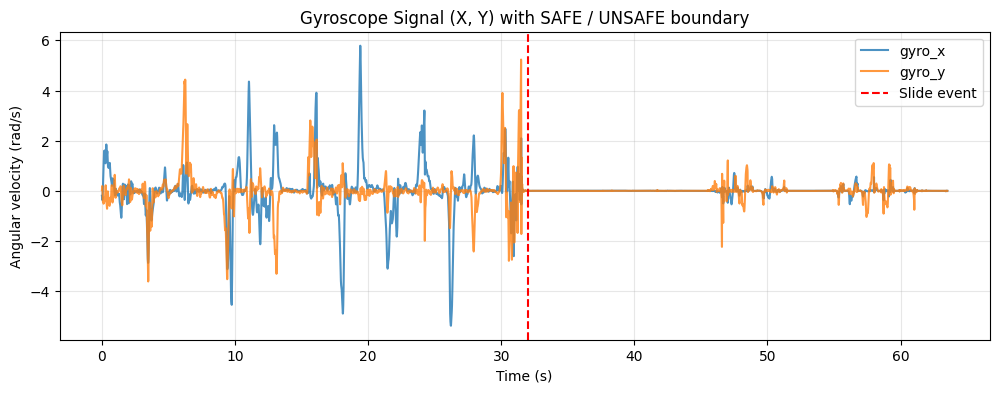

In [9]:
# Mark the slide event and label every raw sample -------------------------
# Set this to the timestamp (seconds) where the object visibly slid off,
# noted during Step 3. Everything before it is SAFE (0), everything after
# is UNSAFE (1).
SLIDE_TIME_SEC = 32.0

df["label"] = (df["time"] >= SLIDE_TIME_SEC).astype(int)
print(df["label"].value_counts().rename({0: "SAFE", 1: "UNSAFE"}))

plt.figure(figsize=(12, 4))
plt.plot(df["time"], df["gyro_x"], label="gyro_x", alpha=0.8)
plt.plot(df["time"], df["gyro_y"], label="gyro_y", alpha=0.8)
plt.axvline(x=SLIDE_TIME_SEC, color="r", linestyle="--", label="Slide event")
plt.title("Gyroscope Signal (X, Y) with SAFE / UNSAFE boundary")
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# 4.2 - 4.4 Sliding window feature extraction (X, Y only) -----------------
def extract_windows(data, window_size=50, step_size=25):
    axes = ["gyro_x", "gyro_y"]
    rows, labels = [], []

    for i in range(0, len(data) - window_size, step_size):
        win = data.iloc[i:i + window_size]
        feats = []
        for a in axes:
            feats += [win[a].mean(), win[a].std(), win[a].max(), win[a].min()]
        rows.append(feats)
        # window label = majority label of the samples inside it
        labels.append(int(win["label"].mean() >= 0.5))

    cols = []
    for a in axes:
        cols += [f"mean_{a}", f"std_{a}", f"max_{a}", f"min_{a}"]
    return pd.DataFrame(rows, columns=cols), np.array(labels)

WINDOW_SIZE = 50   # samples per window (~1 s at 50 Hz)
STEP_SIZE = 25     # 50% overlap

X_df, y = extract_windows(df, WINDOW_SIZE, STEP_SIZE)
X_df["label"] = y

print("Feature table shape:", X_df.shape)
X_df.head()

Feature table shape: (1084, 9)


,mean_gyro_x,std_gyro_x,max_gyro_x,min_gyro_x,mean_gyro_y,std_gyro_y,max_gyro_y,min_gyro_y,label
0,0.114456,0.416309,0.982162,-0.360525,-0.226525,0.270243,0.189612,-0.512875,0
1,0.948296,0.538710,1.573871,0.034100,-0.453843,0.027103,-0.392746,-0.512875,0
2,1.479934,0.143892,1.611362,1.032625,-0.375185,0.089190,-0.192408,-0.490875,0
3,1.389472,0.177759,1.611362,1.098212,-0.103262,0.214930,0.220550,-0.431062,0
4,1.485068,0.265358,1.847954,1.098212,-0.112280,0.239636,0.220550,-0.523050,0


## Step 5 — Train a Model

**Model input: 8 numbers per window**

| # | Feature |
|---|---|
| 1 | mean of gyro_x |
| 2 | std of gyro_x |
| 3 | max of gyro_x |
| 4 | min of gyro_x |
| 5 | mean of gyro_y |
| 6 | std of gyro_y |
| 7 | max of gyro_y |
| 8 | min of gyro_y |

**Output:** 1 number — probability of UNSAFE (0 to 1).

- Architecture: `Input(8) → Dense(16, ReLU) → Dense(8, ReLU) → Dense(1, sigmoid)`
- Loss: binary crossentropy · Optimizer: Adam · Metric: accuracy

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in X_df.columns if c != "label"]
X = X_df[feature_cols].values.astype(np.float32)
y = X_df["label"].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# fit the scaler on training data only, then apply to both splits
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (867, 8)  Test: (217, 8)


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=8,
    verbose=1,
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6471 - loss: 0.6212 - val_accuracy: 0.7143 - val_loss: 0.5467
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7186 - loss: 0.5266 - val_accuracy: 0.7235 - val_loss: 0.4924
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7266 - loss: 0.4815 - val_accuracy: 0.7465 - val_loss: 0.4654
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7497 - loss: 0.4530 - val_accuracy: 0.7512 - val_loss: 0.4450
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7682 - loss: 0.4316 - val_accuracy: 0.7604 - val_loss: 0.4334
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7774 - loss: 0.4183 - val_accuracy: 0.7834 - val_loss: 0.4248
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7901 - loss: 0.4045 - val_accuracy: 0.7926 - val_loss: 0.4146
Epoch 8/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8074 - loss: 0.3932 - val_accuracy: 0

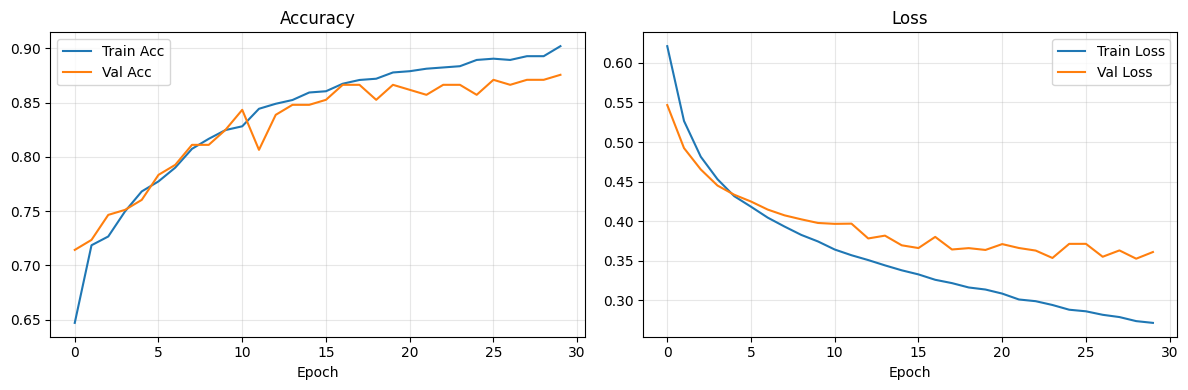

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6 — Evaluate the Model

- Test on unseen data
- Metrics: accuracy, precision, recall, F1-score
- Plot the confusion matrix

In [15]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
)

y_pred_proba = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["SAFE", "UNSAFE"]))

Accuracy : 0.8756
Precision: 0.8716
Recall   : 0.8796
F1-score : 0.8756

              precision    recall  f1-score   support

        SAFE       0.88      0.87      0.88       109
      UNSAFE       0.87      0.88      0.88       108

    accuracy                           0.88       217
   macro avg       0.88      0.88      0.88       217
weighted avg       0.88      0.88      0.88       217



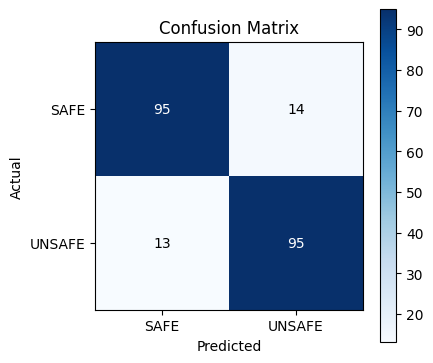

In [16]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["SAFE", "UNSAFE"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["SAFE", "UNSAFE"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Step 7 — Convert Model to TFLite

Convert the trained Keras model to TensorFlow Lite (`.tflite`) format — this strips training-only ops and makes it suitable for edge devices.

In [17]:
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

size_kb = os.path.getsize("model.tflite") / 1024
print(f"Saved model.tflite — {size_kb:.2f} KB")

Saved artifact at '/tmp/tmppa9o35u8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135937327410512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327408400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327409744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327408016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327408208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327407632: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved model.tflite — 3.18 KB


## Step 8 — Optimize the Model

Apply post-training **int8 quantization** to shrink the model further and speed up inference on hardware without a floating-point unit.

In [18]:
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(X_train).batch(1).take(100):
        yield [tf.cast(input_value, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.target_spec.supported_types = [tf.int8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quantized_tflite_model = converter.convert()

with open("model_quantized.tflite", "wb") as f:
    f.write(quantized_tflite_model)

size_float_kb = os.path.getsize("model.tflite") / 1024
size_quant_kb = os.path.getsize("model_quantized.tflite") / 1024
print(f"model.tflite            : {size_float_kb:.2f} KB")
print(f"model_quantized.tflite  : {size_quant_kb:.2f} KB  "
      f"({size_float_kb / size_quant_kb:.1f}x smaller)")

Saved artifact at '/tmp/tmpobs1f0te'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135937327410512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327408400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327409744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327408016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327408208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135937327407632: TensorSpec(shape=(), dtype=tf.resource, name=None)
model.tflite            : 3.18 KB
model_quantized.tflite  : 3.27 KB  (1.0x smaller)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## Step 9 — Convert TFLite to `.h`

Convert the quantized `.tflite` file into a C header file for embedding in firmware (Arduino / ESP32 / STM32 / TensorFlow Lite for Microcontrollers).

In [19]:
# xxd is required; install it if missing (Colab / Debian-based systems)
!apt-get update -qq && apt-get install -y -qq vim-common

!xxd -i model_quantized.tflite > model.h
print("Generated model.h\n")
!head -n 20 model.h

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
/bin/bash: line 1: xxd: command not found
Generated model.h



## Step 10 — Deploy & Make Inferences at the Edge

Integrate `model.h` into an edge device (e.g. Raspberry Pi / microcontroller) using TensorFlow Lite for Microcontrollers (TFLM) or the TFLite runtime. Feed live gyroscope data, preprocess it with the same steps and windowing used above, and run inference.

The cell below simulates that on-device inference loop locally, using the quantized `.tflite` model and a few held-out test windows, so the pipeline can be validated before flashing real hardware.

In [20]:
interpreter = tf.lite.Interpreter(model_path="model_quantized.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

def predict_edge(sample_float):
    sample_int8 = (sample_float / input_scale + input_zero_point).astype(np.int8)
    interpreter.set_tensor(input_details[0]["index"], sample_int8.reshape(1, -1))
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]["index"])
    prob = (out.astype(np.float32) - output_zero_point) * output_scale
    return float(prob.ravel()[0])

LABELS = {0: "SAFE", 1: "UNSAFE"}

print(f"{'gyro_x (rad/s)':>16} {'gyro_y (rad/s)':>16}   Prediction")
for i in range(min(5, len(X_test))):
    prob = predict_edge(X_test[i])
    pred = int(prob >= 0.5)
    gx, gy = X_test[i][0], X_test[i][4]  # mean_gyro_x, mean_gyro_y columns
    print(f"{gx:16.2f} {gy:16.2f}   {LABELS[pred]} ({pred})  actual={LABELS[y_test[i]]}")

  gyro_x (rad/s)   gyro_y (rad/s)   Prediction
           -0.01             0.03   UNSAFE (1)  actual=UNSAFE
           -3.72            -5.85   SAFE (0)  actual=SAFE
           -0.20             0.25   SAFE (0)  actual=SAFE
            0.37            -2.36   SAFE (0)  actual=SAFE
           -0.01             0.03   UNSAFE (1)  actual=UNSAFE


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [21]:
r = 0.05      # radius from the rotation axis to the object, in meters — update to your measurement
g = 9.81

# angular velocity magnitude at the moment of sliding, from the raw data
slide_idx = (df["time"] - SLIDE_TIME_SEC).abs().idxmin()
omega_c = np.sqrt(df.loc[slide_idx, "gyro_x"] ** 2 + df.loc[slide_idx, "gyro_y"] ** 2)

mu_s = (omega_c ** 2) * r / g
print(f"ω_critical ≈ {omega_c:.3f} rad/s")
print(f"Experimental μs ≈ {mu_s:.3f}")

ω_critical ≈ 0.006 rad/s
Experimental μs ≈ 0.000
